### PS-S06E04: LightGBM

This notebook tackles the [**Playground Series – Season 6, Episode 4: Predicting Irrigation Need**](https://www.kaggle.com/competitions/playground-series-s6e4), a competition focused on predicting the irrigation needs of crops. The goal is to classify the required irrigation level into three categories: **Low (0), Medium (1), or High (2)**, based on environmental features including soil moisture, temperature, humidity, and crop variety.

## Introduction

**LightGBM** distinguishes itself with a "leaf-wise" (best-first) tree growth strategy, contrasting with the traditional "level-wise" (depth-wise) approach used by XGBoost. This allows it to converge faster and often capture more complex, non-linear dependencies in physiological data. It handles missing values internally and is highly optimized for memory efficiency and training speed. While LightGBM has native support for categorical features, we will utilize our refined feature engineering pipeline to ensure robust inputs.

The notebook is one of a number of notebooks that explore various models to address this challenge, with the ultimate goal of ensembling these diverse learners. The EDA for this dataset was performed in this notebook: [**PS-S06E04: EDA**](https://www.kaggle.com/code/stephentarter/ps-s06e04-eda).

## Install Needed Packages

In [1]:
%pip install --no-binary lightgbm --config-settings=cmake.define.USE_CUDA=ON lightgbm


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import gc
import sys
import math
import random
import warnings
from pathlib import Path
from typing import Iterable
from IPython.display import display, Markdown, IFrame

# --- Third-party
import numpy as np
import pandas as pd
import lightgbm as lgb
import optuna
from optuna.exceptions import TrialPruned
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import mean_squared_error, roc_auc_score, balanced_accuracy_score
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import RFECV
import matplotlib.pyplot as plt
import seaborn as sns

from ps_s06e04_feature_engineering import FeatureFactory
from ps_s06e04_model_visualizer import ModelVisualizer
from ps_s06e04_experiment_setup import ExperimentSetup

# Notebook settings
warnings.filterwarnings('ignore')

%matplotlib inline

import ipywidgets as widgets
widgets.IntProgress()

IntProgress(value=0)

In [3]:
helper = ExperimentSetup()

# Get the seed, and apply it to all the internals like pandas and numpy
seed = helper.set_seeds()

helper.configure_pandas()
helper.suppress_warnings()

# The target feature
TARGET = 'Irrigation_Need'

# Show GPU be utilized in training
USE_GPU = True

# Recursive Feature Elimination should be performed in the pipeline.
PERFORM_RFE = False

# Optuna tuning should be performed in the pipeline
PERFORM_OPTUNA_TUNING = True

Random seed set to: 10301
Warnings suppressed.


## Read and Examine the Training Dataset

In [4]:
training_df = helper.read_dataset("training")

TRAINING DATASET

   id Soil_Type  Soil_pH  Soil_Moisture  Organic_Carbon  \
0   0     Loamy    4.920         32.580           1.010   
1   1      Clay    7.080         56.610           0.440   
2   2      Clay    5.690         27.710           0.810   
3   3     Sandy    5.650         13.320           1.330   
4   4      Clay    7.960         59.140           0.380   

   Electrical_Conductivity  Temperature_C  Humidity  Rainfall_mm  \
0                    3.050         15.010    50.610      725.990   
1                    2.000         22.920    67.860      985.660   
2                    2.830         26.970    92.220    2,201.700   
3                    0.870         13.320    61.570    1,357.330   
4                    0.960         20.220    91.110    1,538.200   

   Sunlight_Hours  Wind_Speed_kmh  Crop_Type Crop_Growth_Stage  Season  \
0           5.900          16.790  Sugarcane            Sowing    Zaid   
1           6.980           3.390      Wheat        Vegetative  Kharif

## Read and Examine the Test Dataset

In [5]:
test_df = helper.read_dataset("test")

TEST DATASET

       id Soil_Type  Soil_pH  Soil_Moisture  Organic_Carbon  \
0  630000      Silt    6.360         26.190           0.590   
1  630001      Clay    5.870          9.880           1.180   
2  630002     Sandy    6.220         26.550           0.960   
3  630003      Clay    7.680         53.580           0.830   
4  630004     Loamy    5.230         59.020           0.540   

   Electrical_Conductivity  Temperature_C  Humidity  Rainfall_mm  \
0                    2.810         17.830    30.240    1,533.380   
1                    3.260         21.180    78.070      576.050   
2                    0.850         26.870    60.350      545.300   
3                    0.550         41.740    36.050    1,211.030   
4                    2.110         41.080    52.470    1,321.910   

   Sunlight_Hours  Wind_Speed_kmh Crop_Type Crop_Growth_Stage  Season  \
0           5.400           3.000     Maize            Sowing    Rabi   
1           7.220          15.880    Cotton         

## Feature Engineering

In [6]:
# Define which strategies to use for the LightGBM model here:
fe_strategies = [
    'binning'
]

In [7]:
print('Performing initial feature engineering.')

# Initialize and apply the feature factory
feature_engineer = FeatureFactory(strategies=fe_strategies, target=TARGET, seed=seed)

# Fit_transform on training, transform on test
X = feature_engineer.fit_transform(training_df)
X_test = feature_engineer.transform(test_df)

# Encode target labels
target_mapping = {'Low': 0, 'Medium': 1, 'High': 2}
y = training_df[TARGET].map(target_mapping).astype(int)

# Get categorical columns (original + engineered) from FeatureFactory
cat_cols = feature_engineer.get_cat_features(X)
cat_cols = [c for c in cat_cols if c in X.columns]

# LightGBM prefers 'category' dtype for native categorical handling
for c in cat_cols:
    X[c] = X[c].astype('category')
    X_test[c] = X_test[c].astype('category')
    
print(f'Old Feature Count: {training_df.shape[1] - 1}')
print(f'New Feature Count: {X.shape[1]}')
print(X.head())

Performing initial feature engineering.
Old Feature Count: 20
New Feature Count: 19
  Soil_Type  Soil_pH  Soil_Moisture  Organic_Carbon  Electrical_Conductivity  \
0     Loamy    4.920         32.580           1.010                    3.050   
1      Clay    7.080         56.610           0.440                    2.000   
2      Clay    5.690         27.710           0.810                    2.830   
3     Sandy    5.650         13.320           1.330                    0.870   
4      Clay    7.960         59.140           0.380                    0.960   

   Temperature_C  Humidity  Rainfall_mm  Sunlight_Hours  Wind_Speed_kmh  \
0         15.010    50.610      725.990           5.900          16.790   
1         22.920    67.860      985.660           6.980           3.390   
2         26.970    92.220    2,201.700           6.050           3.850   
3         13.320    61.570    1,357.330           9.120           2.310   
4         20.220    91.110    1,538.200           6.950     

## Recursive Feature Elimination

In [8]:
n_jobs = 1 if USE_GPU else -1

# Prepare numerical copy for RFE (RFECV requires numeric types)
X_rfe = X.copy()
cat_cols_rfe = X_rfe.select_dtypes(include=['category', 'object']).columns
for col in cat_cols_rfe:
    X_rfe[col] = X_rfe[col].astype('category').cat.codes

if PERFORM_RFE:    
    # Use a fast LightGBM configuration for selection
    # We use fewer estimators to speed up the pruning process
    clf = lgb.LGBMClassifier(
        n_estimators=200,
        learning_rate=0.1,
        num_leaves=31,
        objective='multiclass',
        num_class=3,
        class_weight='balanced',
        random_state=seed,
        n_jobs=n_jobs,
        importance_type='gain', # Use 'gain' for better quality selection
        verbosity=-1
    )

    # Configure RFECV
    # step=2 or 3 speeds up the process significantly with many features
    rfecv = RFECV(
        estimator=clf,
        step=1, 
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=seed),
        scoring='balanced_accuracy', 
        min_features_to_select=15,
        n_jobs=n_jobs,
        verbose=1
    )

    print('Running Recursive Feature Elimination for LightGBM...')
    rfecv.fit(X_rfe, y)
    
    print(f'Optimal number of features: {rfecv.n_features_}')
    
    # Plot Performance vs Number of Features
    plt.figure(figsize=(10, 6))
    plt.xlabel('Number of features selected')
    plt.ylabel('Cross-validation score (Balanced Accuracy)')
    plt.plot(
        range(rfecv.min_features_to_select, len(rfecv.cv_results_['mean_test_score']) + rfecv.min_features_to_select),
        rfecv.cv_results_['mean_test_score']
    )
    plt.title('LightGBM RFE Results')
    plt.show()

    # Save the selected features
    optimal_cols = X_rfe.columns[rfecv.support_]
else:
    # These optimal features were described at https://www.kaggle.com/competitions/playground-series-s6e4/discussion/687460
    print('Using all columns as optimal features.')
    optimal_cols = pd.Index([
        'Soil_Moisture',
        'Crop_Growth_Stage',
        'Temperature_C',
        'Mulching_Used',
        'Wind_Speed_kmh',
        'Rainfall_mm'
    ])
        
print('\nOptimal Features Count:', len(optimal_cols))
print('Optimal Features:', optimal_cols.tolist())

Using all columns as optimal features.

Optimal Features Count: 6
Optimal Features: ['Soil_Moisture', 'Crop_Growth_Stage', 'Temperature_C', 'Mulching_Used', 'Wind_Speed_kmh', 'Rainfall_mm']


## Optuna Tuning

In [9]:
print("Precomputing fold-wise FE for Optuna (once)...")

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
fold_cache = []

# Ensure optimal_cols is a standard list for filtering
cols_to_keep = list(optimal_cols) if not isinstance(optimal_cols, list) else optimal_cols

for fold, (train_idx, val_idx) in enumerate(skf.split(training_df, y)):
    X_train_fold = training_df.iloc[train_idx].copy()
    X_val_fold   = training_df.iloc[val_idx].copy()
    y_train_fold = y.iloc[train_idx].copy()
    y_val_fold   = y.iloc[val_idx].copy()
    

    fe = FeatureFactory(strategies=fe_strategies, target=TARGET, seed=seed + fold)
    X_train_trans = fe.fit_transform(X_train_fold)
    X_val_trans   = fe.transform(X_val_fold)
    
    # Restrict to optimal column set
    if cols_to_keep is not None:
        final_cols = [c for c in cols_to_keep if c in X_train_trans.columns]
        if not final_cols:
            raise RuntimeError('No overlap between optimal_cols and fold feature columns.')
        X_train_trans = X_train_trans[final_cols]
        X_val_trans   = X_val_trans[final_cols]

    cat_cols = X_train_trans.select_dtypes(include=["category", "object"]).columns.tolist()
    cat_cols = [c for c in cat_cols if c in X_val_trans.columns]

    fold_cache.append((X_train_trans, y_train_fold, X_val_trans, y_val_fold, cat_cols, val_idx))

print("Cached folds:", len(fold_cache))


Precomputing fold-wise FE for Optuna (once)...
Cached folds: 5


In [10]:
n_jobs = 6

def objective(trial):
    params = {
        'n_estimators': 2000,
        'boosting_type': 'gbdt',
        'objective': 'multiclass',
        'num_class': 3,
        'metric': 'None',
        'class_weight': 'balanced',
        
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.05, log=True),
    
        'num_leaves': trial.suggest_int('num_leaves', 8, 32),
        'max_depth': trial.suggest_int('max_depth', 3, 6),
        'min_child_samples': trial.suggest_int('min_child_samples', 20, 100),

        'subsample': trial.suggest_float('subsample', 0.7, 1.0),
        'subsample_freq': trial.suggest_int('subsample_freq', 1, 5),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.8, 1.0),
    
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),

        'feature_pre_filter': False,
        'force_col_wise': True,

        'random_state': seed,
        # 'device_type': 'gpu' if USE_GPU else 'cpu',
        'device_type': 'cpu',  # Forcing for Optuna training
        'n_jobs': n_jobs,
        'verbosity': -1,
    }

    # Set additional parameters if on GPU
    if params['device_type'] == 'gpu':
        params['gpu_platform_id'] =  0
        params['gpu_device_id'] = 0

    oof_preds = np.zeros(len(y), dtype=int)

    for X_train_trans, y_train_fold, X_val_trans, y_val_fold, cat_cols, val_idx in fold_cache:
        # LightGBM requires categorical features to be 'category' dtype, not 'object'
        for col in cat_cols:
            if col in X_train_trans.columns:
                X_train_trans[col] = X_train_trans[col].astype('category')
                X_val_trans[col] = X_val_trans[col].astype('category')
                
        model = lgb.LGBMClassifier(**params)

        model.fit(
            X_train_trans, y_train_fold,
            eval_set=[(X_val_trans, y_val_fold)],
            eval_metric='multi_logloss', # Internal metric for boosting
            categorical_feature=cat_cols,
            callbacks=[
                lgb.early_stopping(100, verbose=False)
            ]
        )
    
        preds = model.predict(X_val_trans)
        oof_preds[val_idx] = preds

        del model
        gc.collect()

        # Report intermediate score to Optuna for pruning
        fold_score = balanced_accuracy_score(y_val_fold, preds)
        trial.report(fold_score, step=fold) # "step" is the fold index
        
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()
            
    return balanced_accuracy_score(y, oof_preds)

In [11]:
if PERFORM_OPTUNA_TUNING:
    print('Starting LightGBM Optuna Optimization...')
    
    # Use MedianPruner for efficiency
    pruner = optuna.pruners.MedianPruner(
        n_startup_trials=5,
        n_warmup_steps=1
    )
    
    study_lgbm = optuna.create_study(
        direction='maximize',
        study_name='lgbm_predict_irrigation_need_optuna', 
        pruner=pruner
    )
    
    study_lgbm.optimize(
        objective,
        n_trials=25,
        show_progress_bar=True,
        timeout=18000,  # 5 hours
    )
    
    print('\nBest Trial:')
    print(f'  Balanced Accuracy: {study_lgbm.best_value:.5f}')
    print('  Params: ', study_lgbm.best_params)
    
    lgbm_best_params = study_lgbm.best_params
else:
    lgbm_best_params = {
        'learning_rate': 0.05435034032542929,
        'num_leaves': 56,
        'max_depth': 3,
        'min_child_samples': 101,
        'subsample': 0.9989615799266536,
        'subsample_freq': 1,
        'colsample_bytree': 0.961657569938817,
        'reg_alpha': 12.13942325224699,
        'reg_lambda': 23.640043123897726
    }
    
    print('\nUsing earlier calculated params:')
    print('  Params: ', lgbm_best_params)
    

[I 2026-04-13 13:18:12,060] A new study created in memory with name: lgbm_predict_irrigation_need_optuna


Starting LightGBM Optuna Optimization...


  0%|          | 0/25 [00:00<?, ?it/s]

[I 2026-04-13 13:28:58,737] Trial 0 finished with value: 0.9690429098253253 and parameters: {'learning_rate': 0.015542343932497567, 'num_leaves': 25, 'max_depth': 5, 'min_child_samples': 20, 'subsample': 0.9807160227091727, 'subsample_freq': 2, 'colsample_bytree': 0.8381548306145099, 'reg_alpha': 0.009715456951284767, 'reg_lambda': 7.082675088789833}. Best is trial 0 with value: 0.9690429098253253.
[I 2026-04-13 13:36:53,887] Trial 1 finished with value: 0.9691759393699527 and parameters: {'learning_rate': 0.016583128930292176, 'num_leaves': 11, 'max_depth': 5, 'min_child_samples': 82, 'subsample': 0.8954066758556357, 'subsample_freq': 5, 'colsample_bytree': 0.970421481119339, 'reg_alpha': 0.01823074185619045, 'reg_lambda': 0.5172258713652512}. Best is trial 1 with value: 0.9691759393699527.
[I 2026-04-13 13:47:23,407] Trial 2 finished with value: 0.9691724956843147 and parameters: {'learning_rate': 0.015064725776958355, 'num_leaves': 22, 'max_depth': 6, 'min_child_samples': 22, 'subsa

## Model Training

In [12]:
# Build LGB parameters from best_params
lgb_tuned_params = {
    **lgbm_best_params,
    'n_estimators': 20000,
    'objective': 'multiclass',
    'metric': 'multi_logloss',
    'num_class': 3,
    'class_weight': 'balanced',
    'boosting_type': 'gbdt',
    'n_jobs': n_jobs,
    'random_state': seed,
    'device_type': 'gpu' if USE_GPU else 'cpu',
    'verbosity': -1,
}

# Set additional parameters if on GPU
if lgb_tuned_params['device_type'] == 'gpu':
    lgb_tuned_params['gpu_platform_id'] =  0
    lgb_tuned_params['gpu_device_id'] = 0

print('Final LightGBM CV Training with OOF / Test probabilities')
print('======================================================')
print('Parameters used for training:')
print(lgb_tuned_params)
print(' ')

# Initialize Standard K-Fold
n_folds = 5
skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=seed)

# Storage for plotting later
eval_results = []
models = []

# Arrays to store results
oof_probs = np.zeros((len(y), 3))
test_probs = np.zeros((len(test_df), 3))
oof_preds = np.zeros(len(y))

for fold, (train_idx, val_idx) in enumerate(skf.split(training_df, y)):
    print(f'\nStarting processing of fold {fold+1}')

    X_train_fold = training_df.iloc[train_idx]
    X_val_fold = training_df.iloc[val_idx]
    y_train_fold = y.iloc[train_idx]
    y_val_fold = y.iloc[val_idx]

    fe = FeatureFactory(strategies=fe_strategies, target=TARGET, seed=seed)
    X_train_trans = fe.fit_transform(X_train_fold)
    X_val_trans = fe.transform(X_val_fold)
    X_test_trans = fe.transform(test_df)
    
    # Restrict to optimal column set
    if cols_to_keep is not None:
        final_cols = [c for c in cols_to_keep if c in X_train_trans.columns]
        if not final_cols:
            raise RuntimeError('No overlap between optimal_cols and fold feature columns.')
        X_train_trans = X_train_trans[final_cols]
        X_val_trans   = X_val_trans[final_cols]
        X_test_trans = X_test_trans[final_cols]

    cat_cols = X_train_trans.select_dtypes(include=["category", "object"]).columns.tolist()
    cat_cols = [c for c in cat_cols if c in X_val_trans.columns]

    # LightGBM requires categorical features to be 'category' dtype, not 'object'
    for col in cat_cols:
        if col in X_train_trans.columns:
            X_train_trans[col] = X_train_trans[col].astype('category')
            X_val_trans[col] = X_val_trans[col].astype('category')
            X_test_trans[col] = X_test_trans[col].astype('category')
            
    model = lgb.LGBMClassifier(**lgb_tuned_params)
    model.fit(
        X_train_trans, y_train_fold,
        eval_set=[(X_train_trans, y_train_fold), (X_val_trans, y_val_fold)],
        categorical_feature=cat_cols,
        callbacks=[
            lgb.early_stopping(200, verbose=False),
            lgb.log_evaluation(period=200)
        ]
    )
    
    # Store history
    eval_results.append(model.evals_result_)
    models.append(model)

    probs = model.predict_proba(X_val_trans)
    preds= np.argmax(probs, axis=1)

    oof_probs[val_idx] = probs
    oof_preds[val_idx] = preds
    
    # Score this fold
    fold_score = balanced_accuracy_score(y_val_fold, preds)
    print(f'Fold {fold+1} Balanced Accuracy: {fold_score:.6f}')
    
    test_probs += model.predict_proba(X_test_trans) / n_folds

    del model
    gc.collect()
    
# Final Metric Calculation
overall_score = balanced_accuracy_score(y, oof_preds)
print(f'\nOverall CV Balanced Accuracy: {overall_score:.5f}')

Final LightGBM CV Training with OOF / Test probabilities
Parameters used for training:
{'learning_rate': 0.024540872010434023, 'num_leaves': 8, 'max_depth': 3, 'min_child_samples': 100, 'subsample': 0.7685147519777769, 'subsample_freq': 4, 'colsample_bytree': 0.9986920737183962, 'reg_alpha': 0.12726447327702403, 'reg_lambda': 0.4225166107101827, 'n_estimators': 20000, 'objective': 'multiclass', 'metric': 'multi_logloss', 'num_class': 3, 'class_weight': 'balanced', 'boosting_type': 'gbdt', 'n_jobs': 6, 'random_state': 10301, 'device_type': 'gpu', 'verbosity': -1, 'gpu_platform_id': 0, 'gpu_device_id': 0}
 

Starting processing of fold 1
[200]	training's multi_logloss: 0.17174	valid_1's multi_logloss: 0.169772
[400]	training's multi_logloss: 0.114155	valid_1's multi_logloss: 0.104489
[600]	training's multi_logloss: 0.0987359	valid_1's multi_logloss: 0.0876462
[800]	training's multi_logloss: 0.0921338	valid_1's multi_logloss: 0.0814235
[1000]	training's multi_logloss: 0.0884174	valid_1's 

### Learning Curves (Train vs. Validation Balanced Accuracy)
This plot shows the **Balanced Accuracy** over boosting iterations. A widening gap between the blue (train) and red (validation) lines indicates overfitting. Because we use early_stopping_rounds, the model terminates once the validation score plateaus.

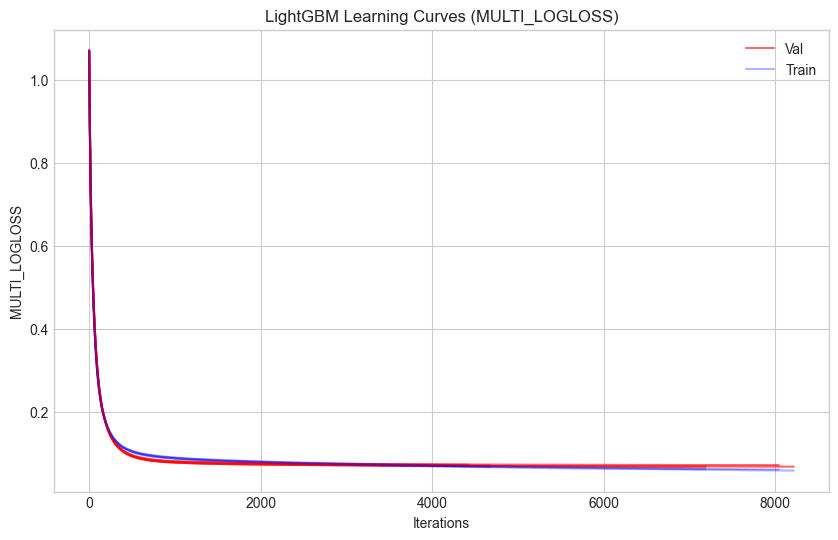

In [13]:
mviz = ModelVisualizer(model_name='LightGBM')

mviz.plot_learning_curves(eval_results, metric='multi_logloss')

### Feature Importance (Gain)

This chart ranks features by how much they improved the model's accuracy (reduced the loss function) whenever they were used in a split.

**Interpretation**  
*   **High Gain:** These are the "Signal" features. The model relies on them heavily.
*   **Low/Zero Gain:** These features were rarely useful. The model mostly ignored them.

**What if engineered features aren't at the top?**  
*   **Don't Panic:** It's okay if raw features like Glucose or BMI are still top. They are strong predictors!
*   **Check Correlations:** If BMI is #1 and your engineered BMI\_Ratio is #50, they might be highly correlated, and the model just chose the simpler one. This is fine.
*   **Re-evaluate:** If an engineered feature is at the very bottom (0 importance), it failed. The hypothesis behind it (e.g., "Age \* Height") likely has no biological relevance.

**What to do with Low Performing Features**  
*   **Zero Importance:** **Drop them.** They add computational cost and noise without adding value.
*   **Low Importance:**  
    *   **Try Dropping:** Sometimes removing "noise" features helps the model focus on the signal (increases score).
  
    *   **Combine Them:** If SkinThickness is weak on its own, try creating an interaction like Insulin / SkinThickness. Sometimes two weak features make one strong feature.

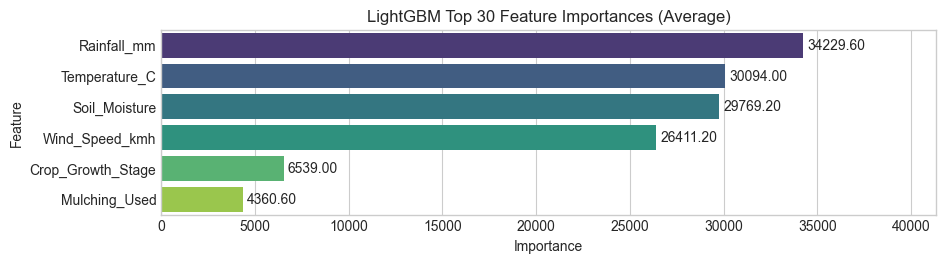

In [14]:
mviz.plot_feature_importance(models, show_values=True)

### Distribution Mismatch
Check if the model is over-predicting a specific irrigation level.  `y` is the actual ground truth, `oof_preds` is the argmax predictions.

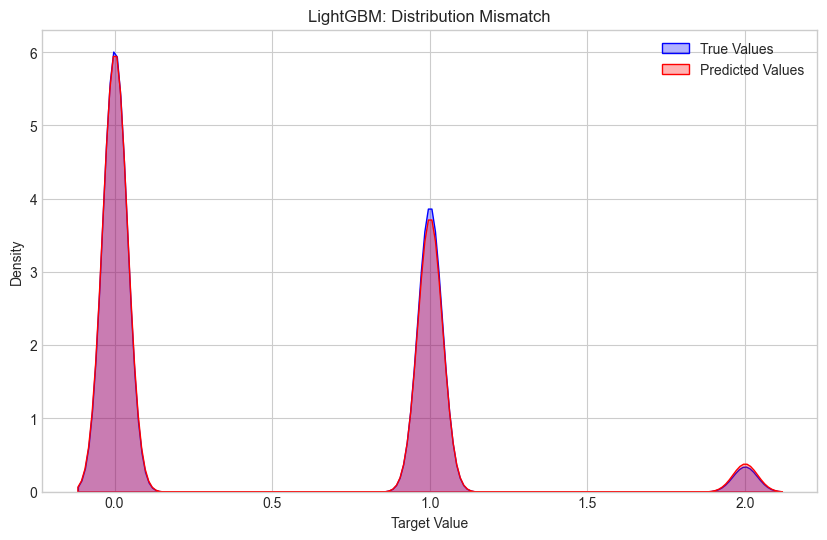

In [15]:
mviz.plot_distribution_mismatch(y_true=y, y_preds=oof_preds)

### ROC Curves (One-vs-Rest)
The ROC curve visualizes the trade-off between the True Positive Rate and False Positive Rate for each class. In this multi-class setting, we look for high AUC scores across all three irrigation levels.

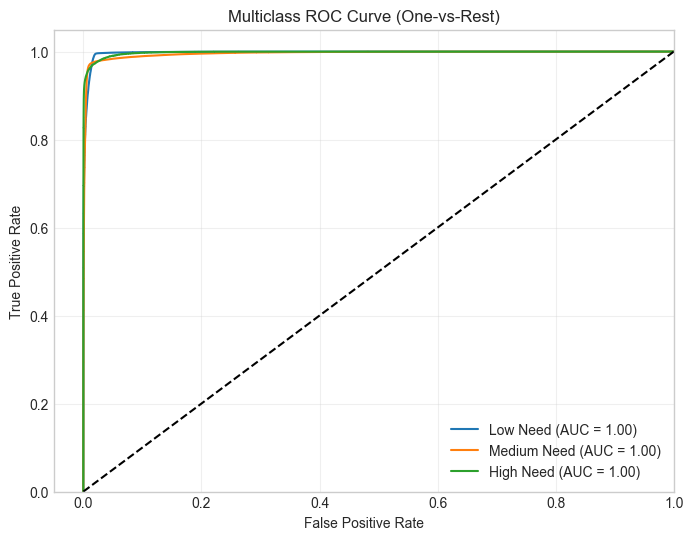

In [16]:
# ROC on OOF
mviz.plot_multiclass_roc_curve(y_true=y, y_score=oof_probs)

Normalized confusion matrix


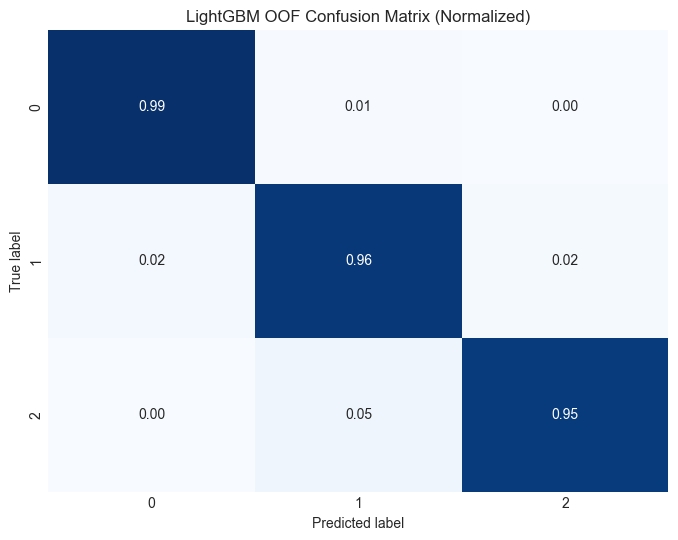

In [17]:
mviz.plot_confusion_matrix(y_true=y, y_pred=oof_preds, classes=[0,1,2], normalize=True, title='LightGBM OOF Confusion Matrix (Normalized)')

## Prepare Submission

In [18]:
submission_df = helper.read_dataset('submission')

target_mapping = {0: 'Low', 1: 'Medium', 2: 'High'}
numeric_preds = np.argmax(test_probs, axis=1)

# Identify the prediction column from the sample submission
pred_col = [c for c in submission_df.columns if c != 'id'][0]
submission_df[pred_col] = pd.Series(numeric_preds).map(target_mapping)

print('SAMPLE SUBMISSION')
display(submission_df.head(20))

SAMPLE SUBMISSION


,id,Irrigation_Need
0,630000,Low
1,630001,Low
2,630002,Low
3,630003,Low
4,630004,Low
5,630005,Medium
6,630006,Low
7,630007,Medium
8,630008,High
9,630009,Low


In [19]:
submission_df.to_csv('submission.csv', index=False)
print('Saved: submission.csv')

Saved: submission.csv


## Save OOF and Test Probabilities

The OOF and test probabilities are saved so that they may be used for comparison of performance differences between the various models, or by a notebook exploring blending the probabilities of the models using some of the tools and techniques outline by Tilii in his excellent [For the (recovering) blind blending addicts](https://www.kaggle.com/competitions/playground-series-s5e12/discussion/651787).

In [20]:
# Ensure directory exists
output_dir = 'predictions'
os.makedirs(output_dir, exist_ok=True)

# Define column names for the probabilities
prob_cols = ['prob_low', 'prob_medium', 'prob_high']

# Save OOF probabilities
# Create a DF for the probabilities first
oof_prob_df = pd.DataFrame(oof_probs, columns=prob_cols)

# Combine with ID and Target
oof_df = pd.concat([
    pd.DataFrame({
        'id': training_df['id'].values,
        'target': y.values
    }),
    oof_prob_df
], axis=1)

oof_df.to_csv(f'{output_dir}/lgb_oof_probs.csv', index=False)

# Save Test probabilities
test_prob_values_df = pd.DataFrame(test_probs, columns=prob_cols)

test_prob_df = pd.concat([
    pd.DataFrame({
        'id': test_df['id'].values
    }),
    test_prob_values_df
], axis=1)
test_prob_df.to_csv(f'{output_dir}/lgb_test_probs.csv', index=False)

print(f'Saved for ensembling:\n - {output_dir}/lgb_oof_probs.csv\n - {output_dir}/lgb_test_probs.csv')

Saved for ensembling:
 - predictions/lgb_oof_probs.csv
 - predictions/lgb_test_probs.csv
